In [31]:
import os
import numpy as np

folder = r"30yrs"   # path to your folder

# List all .grd files
grd_files = [f for f in os.listdir(folder) if f.endswith('.GRD')]

print("Number of files:", len(grd_files))
print("First few files:", grd_files[:5])

# Read the first file
file_path = os.path.join(folder, grd_files[0])

data = np.fromfile(file_path, dtype=np.float32)

print("File:", grd_files[0])
print("Total values:", len(data))
print("4485 blocks:", len(data)/4485)

Number of files: 31
First few files: ['Maxtemp_MaxT_1995.GRD', 'Maxtemp_MaxT_1996.GRD', 'Maxtemp_MaxT_1997.GRD', 'Maxtemp_MaxT_1998.GRD', 'Maxtemp_MaxT_1999.GRD']
File: Maxtemp_MaxT_1995.GRD
Total values: 350765
4485 blocks: 78.20847268673356


In [37]:
file_path = r"30yrs/Maxtemp_MaxT_1995.GRD"

size = os.path.getsize(file_path)

print("File size (bytes):", size)
print("File size (MB):", size/1024/1024)

File size (bytes): 1403060
File size (MB): 1.3380622863769531


In [38]:
file_path = r"30yrs/Maxtemp_MaxT_1995.GRD"

data = np.fromfile(file_path, dtype=np.float32)

daily_grids = data.reshape(365, 31, 31)

print(daily_grids.shape)

(365, 31, 31)


In [40]:
file_path = r"30yrs/Maxtemp_MaxT_1995.GRD"

data = np.fromfile(file_path, dtype=np.float32)

print("Total values:", len(data))

try:
    grid = data.reshape(365, 31, 31)
    print("Success:", grid.shape)
except Exception as e:
    print("Error:", e)

Total values: 350765
Success: (365, 31, 31)


In [41]:
print("Minimum:", np.min(grid))
print("Maximum:", np.max(grid))
print("First 10 values:")
print(grid[0,0,:10])

Minimum: 1.51
Maximum: 99.9
First 10 values:
[99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9]


In [43]:
import numpy as np

grid = np.where(grid == 99.9, np.nan, grid)

In [44]:
missing_count = np.isnan(grid).sum()
total_count = grid.size

print(f"Missing values: {missing_count}")
print(f"Percentage missing: {100*missing_count/total_count:.2f}%")

Missing values: 224374
Percentage missing: 63.97%


In [45]:
#CREATING NEW FOLDER FOR CLEANED DATA
import os

input_folder = "30yrs"
output_folder = "cleaned_data"

os.makedirs(output_folder, exist_ok=True)

In [46]:
for file in os.listdir(input_folder):

    if file.upper().endswith(".GRD"):

        file_path = os.path.join(input_folder, file)

        # Read data
        data = np.fromfile(file_path, dtype=np.float32)

        # Replace missing values
        data[data == 99.9] = np.nan

        # New filename
        new_name = file.replace(".GRD", "_cleaned.npy")

        output_path = os.path.join(output_folder, new_name)

        # Save cleaned file
        np.save(output_path, data)

        print(f"Saved: {new_name}")

print("All files cleaned successfully!")

Saved: Maxtemp_MaxT_1995_cleaned.npy
Saved: Maxtemp_MaxT_1996_cleaned.npy
Saved: Maxtemp_MaxT_1997_cleaned.npy
Saved: Maxtemp_MaxT_1998_cleaned.npy
Saved: Maxtemp_MaxT_1999_cleaned.npy
Saved: Maxtemp_MaxT_2000_cleaned.npy
Saved: Maxtemp_MaxT_2001_cleaned.npy
Saved: Maxtemp_MaxT_2002_cleaned.npy
Saved: Maxtemp_MaxT_2003_cleaned.npy
Saved: Maxtemp_MaxT_2004_cleaned.npy
Saved: Maxtemp_MaxT_2005_cleaned.npy
Saved: Maxtemp_MaxT_2006_cleaned.npy
Saved: Maxtemp_MaxT_2007_cleaned.npy
Saved: Maxtemp_MaxT_2008_cleaned.npy
Saved: Maxtemp_MaxT_2009_cleaned.npy
Saved: Maxtemp_MaxT_2010_cleaned.npy
Saved: Maxtemp_MaxT_2011_cleaned.npy
Saved: Maxtemp_MaxT_2012_cleaned.npy
Saved: Maxtemp_MaxT_2013_cleaned.npy
Saved: Maxtemp_MaxT_2014_cleaned.npy
Saved: Maxtemp_MaxT_2015_cleaned.npy
Saved: Maxtemp_MaxT_2016_cleaned.npy
Saved: Maxtemp_MaxT_2017_cleaned.npy
Saved: Maxtemp_MaxT_2018_cleaned.npy
Saved: Maxtemp_MaxT_2019_cleaned.npy
Saved: Maxtemp_MaxT_2020_cleaned.npy
Saved: Maxtemp_MaxT_2021_cleaned.npy
S

In [47]:
data = np.load(
    "cleaned_data/Maxtemp_MaxT_1995_cleaned.npy"
)

In [48]:
# Load cleaned file
data = np.load("cleaned_data/Maxtemp_MaxT_1995_cleaned.npy")

print("Shape:", data.shape)
print("Total values:", len(data))

print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))

print("NaN count:", np.isnan(data).sum())
print("Valid count:", np.sum(~np.isnan(data)))

Shape: (350765,)
Total values: 350765
Min: 1.51
Max: 47.6
NaN count: 224374
Valid count: 126391


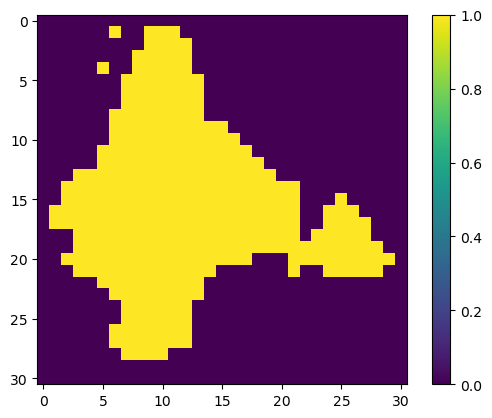

In [52]:

import matplotlib.pyplot as plt

data = np.load("cleaned_data/Maxtemp_MaxT_1995_cleaned.npy")
grid = data.reshape(365,31,31)

mask = ~np.isnan(grid[0])

plt.imshow(mask)
plt.colorbar()
plt.show()

In [54]:
folder = "cleaned_data"

files = sorted([
    f for f in os.listdir(folder)
    if f.endswith(".npy")
])

print("Files:", len(files))
print(files[:3])

Files: 31
['Maxtemp_MaxT_1995_cleaned.npy', 'Maxtemp_MaxT_1996_cleaned.npy', 'Maxtemp_MaxT_1997_cleaned.npy']


In [56]:
points = {
"P1" : (20.319333, 85.460306),
"P2":(19.978167, 85.538667),
"P3": (20.050798, 86.012059),
"P4":(20.374472, 85.981694)}